In [1]:
import os
import random
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, Model, Input
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.applications.vgg19 import VGG19, preprocess_input

2026-04-21 16:14:16.997107: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-21 16:14:17.007418: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776780857.018989   68639 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776780857.023247   68639 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776780857.033126   68639 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
tf.config.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
!nvidia-smi

Tue Apr 21 16:14:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.45.03              Driver Version: 595.71         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        On  |   00000000:01:00.0 Off |                  N/A |
|  0%   40C    P8             28W /  390W |   22383MiB /  24576MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Load dataset

In [4]:

def load_paths(filepath):
    lines = []
    with open(filepath, 'r') as f:
        lines = [line.strip() for line in f if line.strip()]
    
    base_dir = os.path.dirname(filepath) + '/HR/' + lines[0]
    seq_count = len(os.listdir(base_dir))

    result = [""] * seq_count * len(lines) * 4
    print(len(result))
    for i, line in enumerate(lines):
        for j in range(seq_count):
            for k in range(4):
                index = i * seq_count * 4 + j * 4 + k
                result[index] = os.path.join(f"{line}/{j}/im{k+1}.png")
    return result


In [5]:
train_paths = load_paths('/mnt/c/Users/henrik/Downloads/vimeo90k_upscale/train.txt')
val_paths = load_paths('/mnt/c/Users/henrik/Downloads/vimeo90k_upscale/test.txt')

775344
93888


In [6]:


def create_fg_dataset(
    root_path: str, 
    relative_paths: list[str], 
    batch_size: int = 32,
    is_training: bool = True,
    shuffle_buffer_size: int = 1000
):
    """
    Creates a lazy tf.data.Dataset for Frame Generation.
    
    Args:
        root_path: The base directory containing 'LR' and 'HR' folders.
        relative_paths: List of filenames/relative paths of the images (start images).
        batch_size: The batch size for the dataset.
        is_training: If True, shuffles the dataset. If False, keeps original order for validation/testing.
        shuffle_buffer_size: The number of elements to maintain in the shuffle buffer.
    """
    paths_ds = tf.data.Dataset.from_tensor_slices(relative_paths)
    
    # Shuffle early in the pipeline if this is a training dataset
    if is_training:
        paths_ds = paths_ds.shuffle(buffer_size=shuffle_buffer_size, reshuffle_each_iteration=True)
    
    def process_path(rel_path):
        # rel_path format: e.g. "00001/0174/im1.png"
        base_dir = tf.strings.regex_replace(rel_path, r'im\d+\.png$', '')
        idx_str = tf.strings.regex_replace(rel_path, r'.*im(\d+)\.png$', r'\1')
        idx = tf.strings.to_number(idx_str, out_type=tf.int32)
        
        def get_img(offset):
            new_idx = idx + offset
            new_name = tf.strings.join(['im', tf.strings.as_string(new_idx), '.png'])
            # Using separator='' because base_dir has a trailing slash and root_path + 'HR' can be combined manually
            hr_path = tf.strings.join([root_path, '/', 'HR', '/', base_dir, new_name], separator='')
            
            img = tf.io.read_file(hr_path)
            img = tf.image.decode_png(img, channels=3)
            img = tf.cast(img, tf.float32) / 255.0
            img.set_shape([None, None, 3])
            return img
            
        img1 = get_img(0) # Input 1: im(N)
        img2 = get_img(2) # Input 2: im(N+2)
        img_target = get_img(3) # Output: im(N+3)
        
        return (img1, img2), img_target

    # Use map to lazily load and transform the images automatically
    dataset = paths_ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Batch the dataset
    dataset = dataset.batch(batch_size, drop_remainder=is_training)
    
    # Prefetch data to the GPU/Accelerator to prevent I/O bottlenecks
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    
    return dataset

In [7]:

root_dir = "/mnt/c/Users/henrik/Downloads/vimeo90k_upscale/"
train_files = random.sample(train_paths, int(len(train_paths) * 0.05))
val_files = random.sample(val_paths, int(len(val_paths) * 0.05))

# Training dataset (Shuffled and drops incomplete batches)
train_ds = create_fg_dataset(root_dir, train_files, batch_size=32, is_training=True)
# 
# # Validation dataset (Not shuffled, keeps all data)
val_ds = create_fg_dataset(root_dir, val_files, batch_size=32, is_training=False)

I0000 00:00:1776780875.698073   68639 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21548 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:01:00.0, compute capability: 8.6


## Dummy model

In [8]:
import tensorflow as tf

def create_dummy_model(width, height):
    inp1 = tf.keras.layers.Input(shape=(height, width, 3))
    inp2 = tf.keras.layers.Input(shape=(height, width, 3))
    model = tf.keras.Model(inputs=[inp1, inp2], outputs=inp2)
    return model
dummy_model = create_dummy_model(64, 64)

# 2. Define a custom metric for PSNR
def psnr_metric(y_true, y_pred):
    # Calculate PSNR manually to avoid Keras graph-mode Assert issues in tf.image.psnr
    # We add a small epsilon (1e-10) to the MSE to prevent the result from becoming 'inf'
    mse = tf.reduce_mean(tf.square(y_true - y_pred), axis=[1, 2, 3])
    # PSNR = 10 * log10(max_val^2 / MSE). Here max_val is 1.0.
    # tf.math.log is natural log, so we divide by log(10) to get log10.
    return 10.0 * (tf.math.log(1.0 / (mse + 1e-10)) / tf.math.log(10.0))

# 3. Compile the model with MSE loss and our PSNR metric
dummy_model.compile(
    optimizer='adam', # Optimizer isn't actually used since no weights, but required for compile
    loss='mse',
    metrics=[psnr_metric]
)


In [9]:
dummy_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
print("Evaluating linear upscaling dummy model on the entire validation dataset...")

# 4. Use Keras built-in .evaluate() on the validation dataset (val_ds)
evaluation_results = dummy_model.evaluate(val_ds)

print("-" * 30)
print(f"Validation Mean Squared Error (Loss): {evaluation_results[0]:.4f}")
print(f"Validation Mean PSNR:                 {evaluation_results[1]:.2f} dB")

Evaluating linear upscaling dummy model on the entire validation dataset...


I0000 00:00:1776780898.073999  105601 service.cc:152] XLA service 0x7ac684014be0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776780898.074034  105601 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
I0000 00:00:1776780898.088514  105601 cuda_dnn.cc:529] Loaded cuDNN version 92000


  9/147 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0051 - psnr_metric: 29.0902

I0000 00:00:1776780898.287174  105601 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 0.0063 - psnr_metric: 28.8365
------------------------------
Validation Mean Squared Error (Loss): 0.0063
Validation Mean PSNR:                 28.84 dB


In [12]:
dummy_model.save('framegen_dummy.keras')

## Frame gen

In [12]:
def create_framegen(input_shape=(None, None, 3)):
    input1 = Input(shape=input_shape, name='input1')
    input2 = Input(shape=input_shape, name='input2')

    # Concatenate the two frames
    x = layers.Concatenate()([input1, input2])
    
    # Lightweight feature extraction
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.Conv2D(16, (3, 3), padding='same', activation='relu')(x)
    
    # Predict residual difference
    residual = layers.Conv2D(3, (3, 3), padding='same', activation='linear')(x)
    
    # Calculate average of the two frames as a base
    base_frame = layers.Average()([input1, input2])
    
    # Add residual to the base average frame to get the predicted frame
    outputs = layers.Add()([base_frame, residual])

    model = models.Model(
        inputs=[input1, input2], 
        outputs=outputs, 
        name='lightweight_framegen'
    )
    
    return model

model = create_framegen()
model.summary()

Model: "lightweight_framegen"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input1 (InputLayer) │ (None, None,      │          0 │ -                 │
│                     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input2 (InputLayer) │ (None, None,      │          0 │ -                 │
│                     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, None,      │          0 │ input1[0][0],     │
│ (Concatenate)       │ None, 6)          │            │ input2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, None,      │      1,760 │ concatenate[0][0] │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, None,      │      9,248 │ conv2d[0][0]      │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, None,      │      4,624 │ conv2d_1[0][0]    │
│                     │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average (Average)   │ (None, None,      │          0 │ input1[0][0],     │
│                     │ None, 3)          │            │ input2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, None,      │        435 │ conv2d_2[0][0]    │
│                     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, None,      │          0 │ average[0][0],    │
│                     │ None, 3)          │            │ conv2d_3[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 16,067 (62.76 KB)

 Trainable params: 16,067 (62.76 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
import os


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[psnr_metric]
)

# 1. Ensure the checkpoint directory exists
checkpoint_dir = "./checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, "best_fg_model.keras")

# 2. Define the Callbacks
callbacks = [
    # Save the model whenever validation PSNR improves
    ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_psnr_metric", # We monitor our custom metric from compile()
        mode="max",                # We want maximum PSNR
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    
    # Reduce learning rate if validation loss stops improving
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,       # Halve the learning rate
        patience=3,       # Wait 3 epochs before reducing
        min_lr=1e-6,      # Minimum learning rate lower bound
        verbose=1
    ),
    
    # Stop training early if validation loss hasn't improved for a long time
    EarlyStopping(
        monitor="val_loss",
        patience=7,                       # Wait 7 epochs before stopping
        restore_best_weights=True,        # Automatically revert to the best epoch
        verbose=1
    )
]

print("Starting training...")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=400,
    callbacks=callbacks
)

Starting training...
Epoch 1/400


2026-04-21 13:08:13.074596: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


1210/1211 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0047 - psnr_metric: 28.2065
Epoch 1: val_psnr_metric improved from None to 28.52198, saving model to ./checkpoints/best_fg_model.keras

Epoch 1: finished saving model to ./checkpoints/best_fg_model.keras
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 57s 44ms/step - loss: 0.0044 - psnr_metric: 28.6901 - val_loss: 0.0046 - val_psnr_metric: 28.5220 - learning_rate: 0.0010
Epoch 2/400
1210/1211 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0039 - psnr_metric: 29.3744
Epoch 2: val_psnr_metric improved from 28.52198 to 28.92019, saving model to ./checkpoints/best_fg_model.keras

Epoch 2: finished saving model to ./checkpoints/best_fg_model.keras
1211/1211 ━━━━━━━━━━━━━━━━━━━━ 35s 29ms/step - loss: 0.0039 - psnr_metric: 29.3931 - val_loss: 0.0043 - val_psnr_metric: 28.9202 - learning_rate: 0.0010
Epoch 3/400
1209/1211 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0038 - psnr_metric: 29.6386
Epoch 3: val_psnr_metric improved from 28.92019 to 29.18446, saving 

## Visualization

In [14]:
import matplotlib.pyplot as plt
import tensorflow as tf

def visualize_dataset_element(dataset, index, model=None):
    """
    Fetches an element at the given index from the dataset.
    If a model is provided, shows LR inputs, Generated Output (with PSNR), and HR Target image.
    Otherwise, displays just LR inputs and HR target.
    """
    # Unbatch to access by raw element index
    unbatched = dataset.unbatch()
    
    for inputs, hr in unbatched.skip(index).take(1):
        lr1, lr2 = inputs
        lr1_np = lr1.numpy()
        lr2_np = lr2.numpy()
        hr_np = hr.numpy()
        
        if model is not None:
            # Predict requires a batch dimension
            lr1_batch = tf.expand_dims(lr1, 0)
            lr2_batch = tf.expand_dims(lr2, 0)
            pred = model([lr1_batch, lr2_batch])
            
            # Squeeze batch dimension and clip to valid image range
            pred_img = tf.clip_by_value(pred[0], 0.0, 1.0)
            
            # Calculate PSNR
            psnr = tf.image.psnr(hr, pred_img, max_val=1.0).numpy()
            
            fig, axes = plt.subplots(1, 4, figsize=(20, 5))
            axes[0].imshow(lr1_np)
            axes[0].set_title(f"LR Input 1\n{lr1_np.shape}")
            axes[0].axis('off')

            axes[1].imshow(lr2_np)
            axes[1].set_title(f"LR Input 2\n{lr2_np.shape}")
            axes[1].axis('off')
            
            axes[2].imshow(pred_img.numpy())
            axes[2].set_title(f"Generated Output\nPSNR: {psnr:.2f} dB")
            axes[2].axis('off')
            
            axes[3].imshow(hr_np)
            axes[3].set_title(f"HR Target\n{hr_np.shape}")
            axes[3].axis('off')
            
        else:
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            axes[0].imshow(lr1_np)
            axes[0].set_title(f"LR Input 1\n{lr1_np.shape}")
            axes[0].axis('off')

            axes[1].imshow(lr2_np)
            axes[1].set_title(f"LR Input 2\n{lr2_np.shape}")
            axes[1].axis('off')
            
            axes[2].imshow(hr_np)
            axes[2].set_title(f"HR Target\n{hr_np.shape}")
            axes[2].axis('off')
            
        plt.tight_layout()
        plt.show()
        return

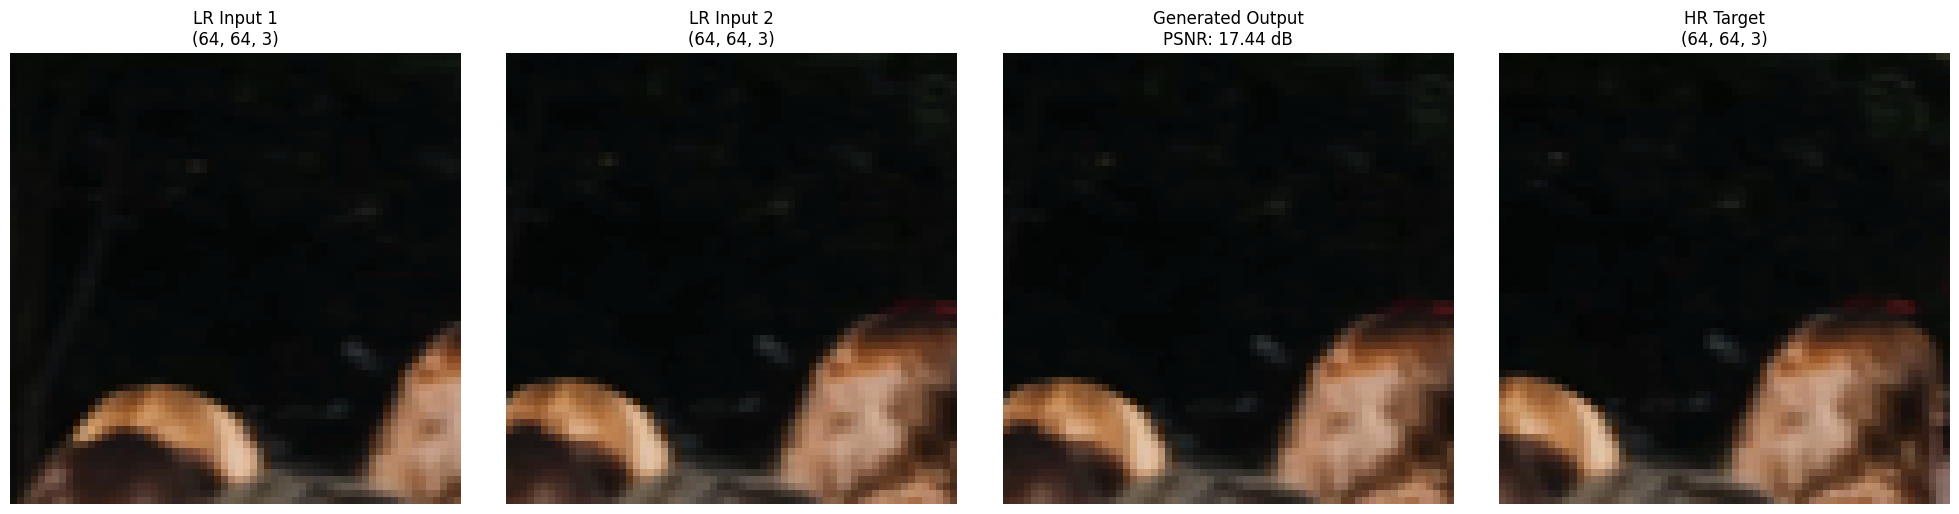

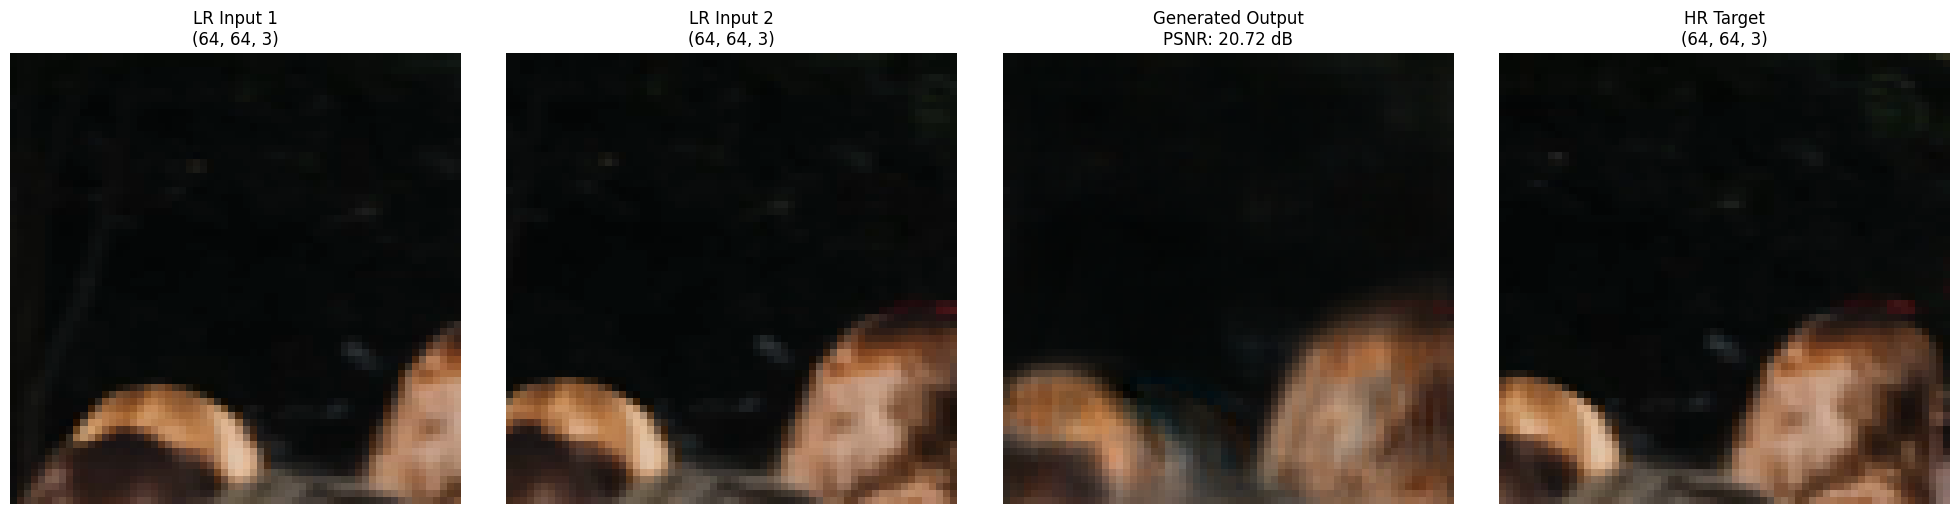

In [42]:
visualize_dataset_element(val_ds, index=331, model=dummy_model)
visualize_dataset_element(val_ds, index=331, model=model)

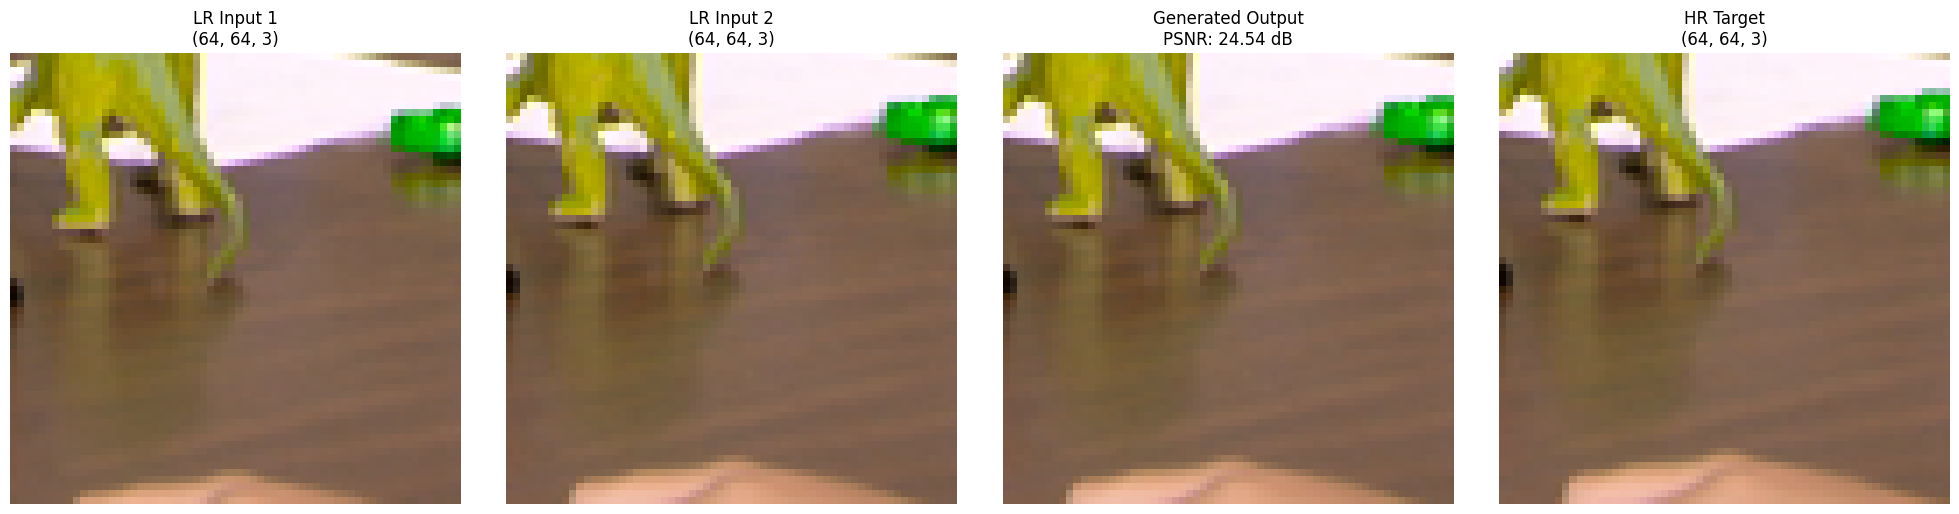

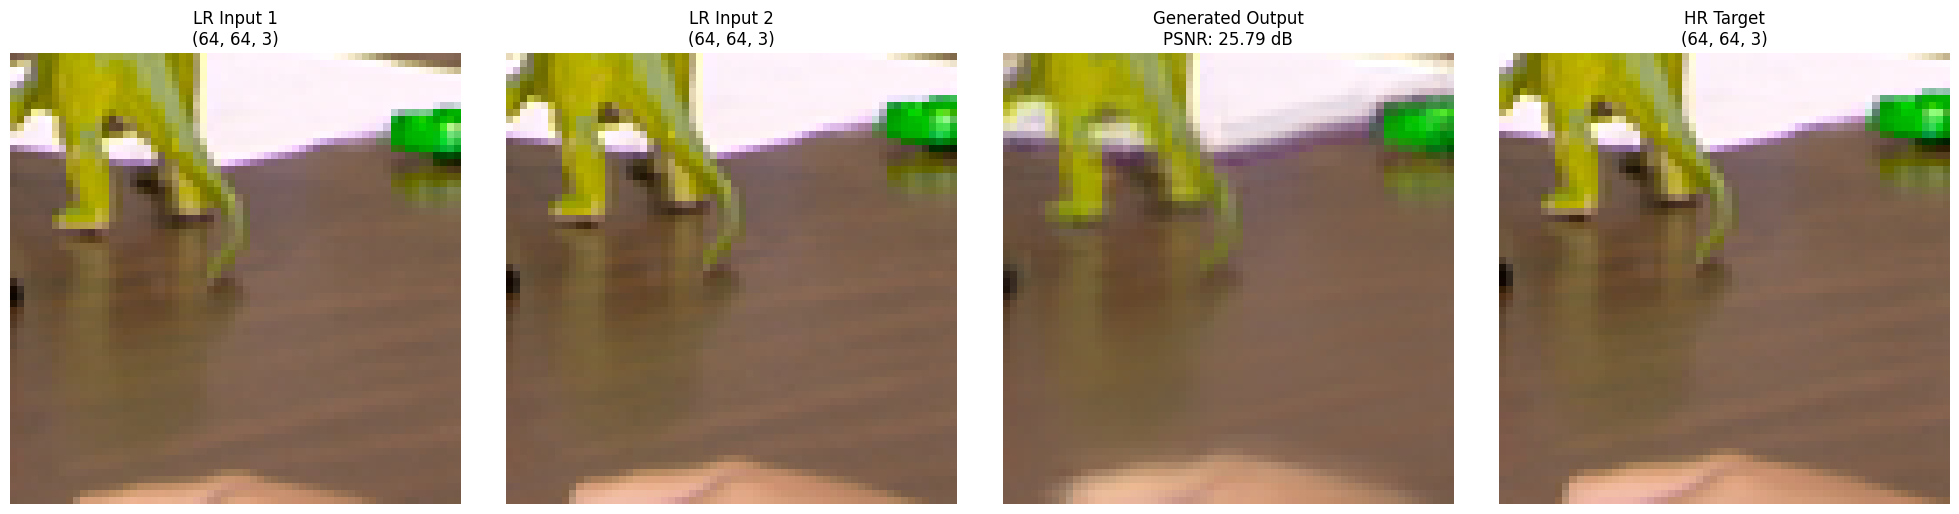

In [43]:
index = random.randint(0, 1000)
visualize_dataset_element(val_ds, index, model=dummy_model)
visualize_dataset_element(val_ds, index, model=model)

In [41]:
index

331